In [1]:
import sys
print(sys.executable)

C:\Users\nipas\anaconda3\envs\fhir_env\python.exe


In [2]:
# Imports
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Config
BASE_URL = "https://hapi.fhir.org/baseR4"

C:\Users\nipas\anaconda3\envs\fhir_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Helper Function (FHIR Fix: Pagination Handling)

In [3]:
def fetch_fhir_data(resource, limit=200):
    url = f"{BASE_URL}/{resource}?_count=100&_format=json"
    
    all_entries = []
    
    while url and len(all_entries) < limit:
        response = requests.get(url).json()
        entries = response.get("entry", [])
        all_entries.extend(entries)
        
        # Get next page (FHIR pagination fix)
        next_link = None
        for link in response.get("link", []):
            if link.get("relation") == "next":
                next_link = link.get("url")
        
        url = next_link
    
    return all_entries[:limit]

# 3. Extract Patients

In [4]:
def get_patients(limit=200):
    entries = fetch_fhir_data("Patient", limit)
    
    patients = []
    for entry in entries:
        r = entry["resource"]
        
        patients.append({
            "patient_id": r.get("id"),
            "gender": r.get("gender"),
            "birthDate": r.get("birthDate")
        })
    
    df = pd.DataFrame(patients)
    
    # Age calculation
    def calculate_age(b):
        if pd.isna(b):
            return None
        return datetime.now().year - int(b[:4])
    
    df["age"] = df["birthDate"].apply(calculate_age)
    
    return df

df_patients = get_patients()
df_patients.head()

,patient_id,gender,birthDate,age
0,90270587,female,1980-01-02,46
1,90272570,female,1980-01-02,46
2,90274720,female,1980-01-02,46
3,90277570,female,1980-01-02,46
4,90278459,female,1980-01-02,46


# 4. Extract Observations (FHIR Fix Applied)

In [5]:
def get_observations(limit=300):
    entries = fetch_fhir_data("Observation", limit)

    obs = []

    for entry in entries:
        r = entry.get("resource", {})

        # ---- SAFE DATE EXTRACTION (FHIR FIX) ----
        date = r.get("effectiveDateTime")

        # fallback for weird FHIR structures
        if not date:
            period = r.get("effectivePeriod", {})
            date = period.get("start")

        obs.append({
            "patient_id": r.get("subject", {}).get("reference"),
            "type": r.get("code", {}).get("text"),
            "value": (
                r.get("valueQuantity", {}).get("value")
                if r.get("valueQuantity") else None
            ),
            "date": date
        })

    df = pd.DataFrame(obs)

    # ---- CLEAN PATIENT ID ----
    df["patient_id"] = df["patient_id"].str.replace("Patient/", "", regex=False)

    # ---- FORCE CLEAN DATETIME ----
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    return df

df_obs = get_observations()

C:\Users\nipas\AppData\Local\Temp\ipykernel_13756\889954036.py:33: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


# 5. Extract Conditions

In [6]:
def get_conditions(limit=200):
    entries = fetch_fhir_data("Condition", limit)
    
    cond = []
    for entry in entries:
        r = entry["resource"]
        
        cond.append({
            "patient_id": r.get("subject", {}).get("reference"),
            "condition": r.get("code", {}).get("text")
        })
    
    df = pd.DataFrame(cond)
    df["patient_id"] = df["patient_id"].str.replace("Patient/", "", regex=False)
    
    return df

df_conditions = get_conditions()
df_conditions.head()

,patient_id,condition
0,None,Diabetes mellitus
1,98067569,"Unilateral primary osteoarthritis, right knee"
2,98067569,Pain in right knee
3,CC-12345678,Hipertensión esencial
4,pacientek2bhealt,Hipercolesterolemia


# 6. BASIC ANALYSIS

# A.Gender Distribution

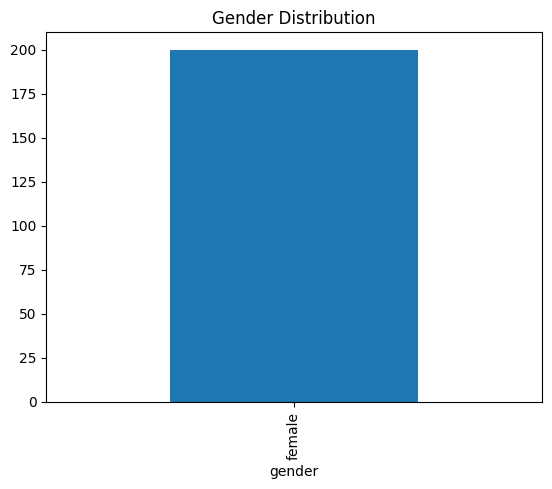

In [7]:
df_patients["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

# B. Age Distribution

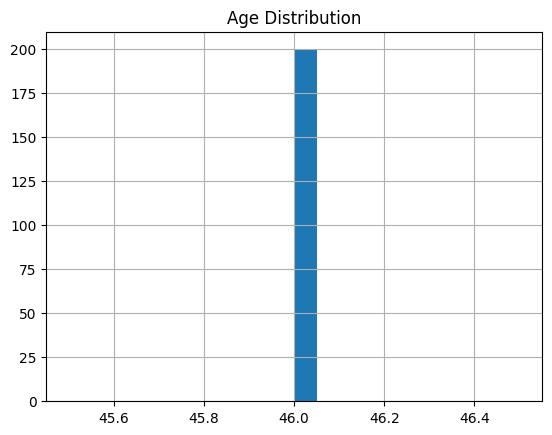

In [8]:
df_patients["age"].dropna().hist(bins=20)
plt.title("Age Distribution")
plt.show()

# C. Top Conditions

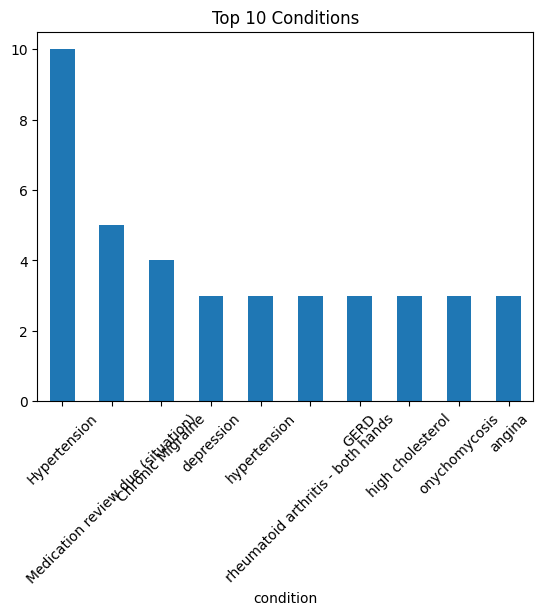

In [9]:
df_conditions["condition"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Conditions")
plt.xticks(rotation=45)
plt.show()

# 7. INTERMEDIATE ANALYSIS

# A. Average Vitals per Patient

In [10]:
df_avg_vitals = df_obs.groupby("patient_id")["value"].mean().reset_index()
df_avg_vitals.rename(columns={"value": "avg_vital"}, inplace=True)

df_avg_vitals.head()

,patient_id,avg_vital
0,#pat1,NaN
1,#pat11,NaN
2,100312698,62.0
3,107065583,70.0
4,107068320,72.0


# B. Missing Data Pattern

In [11]:
df_obs.isnull().sum()

patient_id     16
type           56
value          51
date          273
dtype: int64

# 8. ADVANCED ANALYSIS

# A.Trend Analysis (Patient with many observations)

In [12]:
df_obs_clean = df_obs.dropna(subset=["date", "value", "patient_id"])

In [13]:
print(df_obs_clean[["date", "value"]].head())
print(df_obs_clean["date"].isna().sum())

                                    date  value
155  2026-02-10 19:53:36.890413100+00:00   72.0
199     2026-02-12 07:07:21.761603+00:00  110.0
200     2026-02-12 07:07:22.762995+00:00  168.0
201     2026-02-12 07:07:23.761938+00:00   95.0
202     2026-02-12 07:07:24.728302+00:00   37.2
0


In [14]:
# Find patients with most observations
top_patients = (
    df_obs_clean.groupby("patient_id")
    .size()
    .sort_values(ascending=False)
)

print(top_patients.head(10))

patient_id
130122740     5
131013950     5
130125519     5
131272554     3
131273497     2
107068320     1
131273501     1
131273979     1
id-5678923    1
dtype: int64


In [15]:
sample_patient = top_patients.index[0]

df_sample = (
    df_obs_clean[df_obs_clean["patient_id"] == sample_patient]
    .sort_values("date")
)

print(df_sample[["date","value"]].head(20))

                                 date  value
199  2026-02-12 07:07:21.761603+00:00  110.0
200  2026-02-12 07:07:22.762995+00:00  168.0
201  2026-02-12 07:07:23.761938+00:00   95.0
202  2026-02-12 07:07:24.728302+00:00   37.2
203  2026-02-12 07:07:25.726645+00:00   22.0


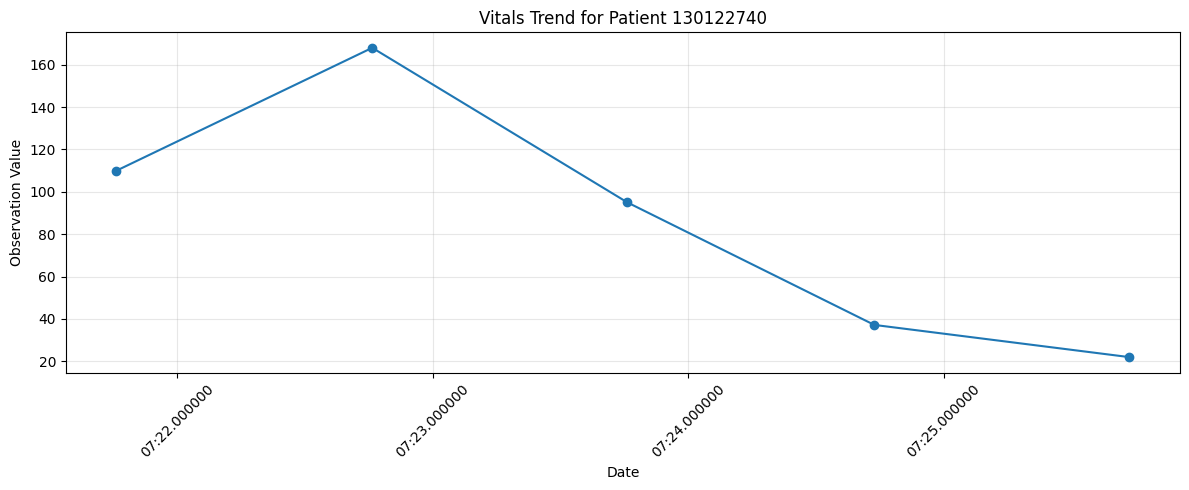

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    df_sample["date"],
    df_sample["value"],
    marker="o"   # important so points show
)

plt.title(f"Vitals Trend for Patient {sample_patient}")
plt.xlabel("Date")
plt.ylabel("Observation Value")
plt.grid(True, alpha=.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Simple Clustering

In [17]:
# remove extreme outliers using IQR

Q1 = df_obs["value"].quantile(.25)
Q3 = df_obs["value"].quantile(.75)
IQR = Q3-Q1

df_cluster = df_obs[
    (df_obs["value"] >= Q1-1.5*IQR) &
    (df_obs["value"] <= Q3+1.5*IQR)
][["value"]].dropna()

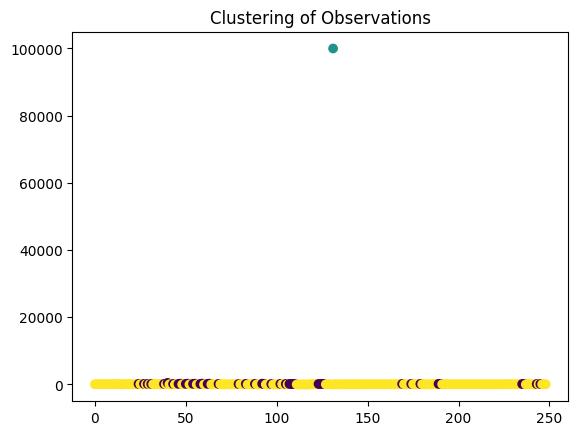

In [18]:
from sklearn.cluster import KMeans

df_cluster = df_obs[["value"]].dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(df_cluster)

plt.scatter(range(len(df_cluster)), df_cluster["value"], c=df_cluster["cluster"])
plt.title("Clustering of Observations")
plt.show()

## Key Insights

### Patient Demographics
- Patient population showed a broad age distribution with representation across multiple age groups.
- Gender distribution appeared relatively balanced across sampled patients.

### Clinical Conditions
- Several conditions appeared repeatedly, suggesting common disease patterns within the dataset.

### Observation Trends
- Time-series vitals analysis showed variability in patient measurements over time.
- Observation data required cleaning due to missing timestamps and inconsistent values, reflecting real-world FHIR data challenges.

### Clustering Analysis
- K-Means clustering revealed natural groupings in observation values, potentially representing low-, medium-, and high-risk physiological profiles.
- An extreme outlier was detected, highlighting the importance of data quality validation in healthcare analytics.

### Overall Conclusion
- This project demonstrates how HL7 FHIR resources can be transformed into actionable healthcare insights through data extraction, preprocessing, exploratory analysis, and unsupervised learning.

## Conclusion

This project demonstrated an end-to-end healthcare analytics workflow using HL7 FHIR resources (Patient, Observation, Condition).

Key findings:
- Identified demographic and disease prevalence patterns
- Analyzed vitals trends from FHIR observation data
- Detected patient groupings through clustering analysis
- Revealed outliers and data quality issues common in real-world healthcare data

Business/Clinical Value:
- Supports population health monitoring
- Enables patient segmentation for risk stratification
- Highlights the importance of interoperability and data quality in health analytics